<a href="https://colab.research.google.com/github/Amitabh-Phule/Reinforcement-Learning/blob/main/RL_Exp_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Title**
  Multi-Armed Bandit Problem

## **Aim**

To implement ε-greedy action selection for the Multi-Armed Bandit Problem and compare exploration and exploitation strategies.

## **Theory**

The Multi-Armed Bandit Problem is a reinforcement learning problem where an agent has multiple actions or arms to choose from.

Each arm provides a reward, but initially the agent does not know which arm provides the highest reward.

There are two important strategies:

1. Exploration:
   The agent tries different arms to discover which arm gives better rewards.

2. Exploitation:
   The agent selects the arm that currently appears to give the highest reward.

The ε-greedy method balances exploration and exploitation.

With probability ε, the agent chooses a random action for exploration.

With probability (1 - ε), the agent chooses the action with the highest estimated reward for exploitation.

For example, when ε = 0.1:

10% of the time → Exploration
90% of the time → Exploitation

## **Algorithm**

1. Initialize the number of arms.
2. Initialize the estimated reward of each arm to zero.
3. Initialize the number of times each arm has been selected.
4. Set the value of ε.
5. For each step:
   a. Generate a random number.
   b. If the random number is less than ε, select a random arm.
   c. Otherwise, select the arm with the highest estimated reward.
6. Generate a reward for the selected arm.
7. Update the estimated reward of the selected arm.
8. Repeat the process for the specified number of steps.
9. Calculate the total and average reward.
10. Display the estimated rewards and arm selection frequency.
11. Plot the cumulative reward and arm selection frequency.

## **Import Required Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Define the Multi-Armed Bandit Environment**

In [2]:
# True average reward of each arm
true_rewards = [1.0, 1.5, 2.0, 0.5, 1.2]

# Number of arms
n_arms = len(true_rewards)

print("Number of arms:", n_arms)
print("True average rewards:", true_rewards)

Number of arms: 5
True average rewards: [1.0, 1.5, 2.0, 0.5, 1.2]


## **Implement ε-Greedy Action Selection**

In [3]:
def epsilon_greedy(epsilon, n_steps=1000):

    # Estimated reward for each arm
    estimated_rewards = np.zeros(n_arms)

    # Number of times each arm is selected
    action_counts = np.zeros(n_arms)

    # Store rewards
    rewards = []

    # Store selected actions
    actions = []

    for step in range(n_steps):

        # Exploration
        if np.random.random() < epsilon:
            action = np.random.randint(n_arms)

        # Exploitation
        else:
            action = np.argmax(estimated_rewards)

        # Generate reward
        reward = np.random.normal(true_rewards[action], 1)

        # Update action count
        action_counts[action] += 1

        # Update estimated reward
        estimated_rewards[action] += (
            (reward - estimated_rewards[action])
            / action_counts[action]
        )

        rewards.append(reward)
        actions.append(action)

    return (
        np.array(rewards),
        np.array(actions),
        estimated_rewards,
        action_counts
    )

## **Run the ε-Greedy Experiment**

In [4]:
# Set experiment parameters
epsilon = 0.1
n_steps = 1000

# Run ε-greedy algorithm
rewards, actions, estimated_rewards, action_counts = epsilon_greedy(
    epsilon,
    n_steps
)

print("Epsilon:", epsilon)
print("Number of steps:", n_steps)

print("\nEstimated rewards:")

for i in range(n_arms):
    print(f"Arm {i+1}: {estimated_rewards[i]:.3f}")

print("\nNumber of times each arm was selected:")

for i in range(n_arms):
    print(f"Arm {i+1}: {int(action_counts[i])}")

print("\nTotal reward:", round(np.sum(rewards), 2))
print("Average reward:", round(np.mean(rewards), 3))

Epsilon: 0.1
Number of steps: 1000

Estimated rewards:
Arm 1: 0.952
Arm 2: 1.506
Arm 3: 1.925
Arm 4: 0.438
Arm 5: 1.304

Number of times each arm was selected:
Arm 1: 104
Arm 2: 15
Arm 3: 840
Arm 4: 20
Arm 5: 21

Total reward: 1774.73
Average reward: 1.775


## **Calculate Exploration and Exploitation**

In [5]:
# Reset random seed
np.random.seed(42)

exploration_count = 0
exploitation_count = 0

estimated_rewards_temp = np.zeros(n_arms)
action_counts_temp = np.zeros(n_arms)

for step in range(n_steps):

    random_value = np.random.random()

    # Exploration
    if random_value < epsilon:
        action = np.random.randint(n_arms)
        exploration_count += 1

    # Exploitation
    else:
        action = np.argmax(estimated_rewards_temp)
        exploitation_count += 1

    # Generate reward
    reward = np.random.normal(true_rewards[action], 1)

    # Update count
    action_counts_temp[action] += 1

    # Update estimated reward
    estimated_rewards_temp[action] += (
        (reward - estimated_rewards_temp[action])
        / action_counts_temp[action]
    )

print("Exploration decisions:", exploration_count)
print("Exploitation decisions:", exploitation_count)

print(
    "Exploration percentage:",
    round(exploration_count / n_steps * 100, 2),
    "%"
)

print(
    "Exploitation percentage:",
    round(exploitation_count / n_steps * 100, 2),
    "%"
)

Exploration decisions: 113
Exploitation decisions: 887
Exploration percentage: 11.3 %
Exploitation percentage: 88.7 %


## **Plot Cumulative Reward**

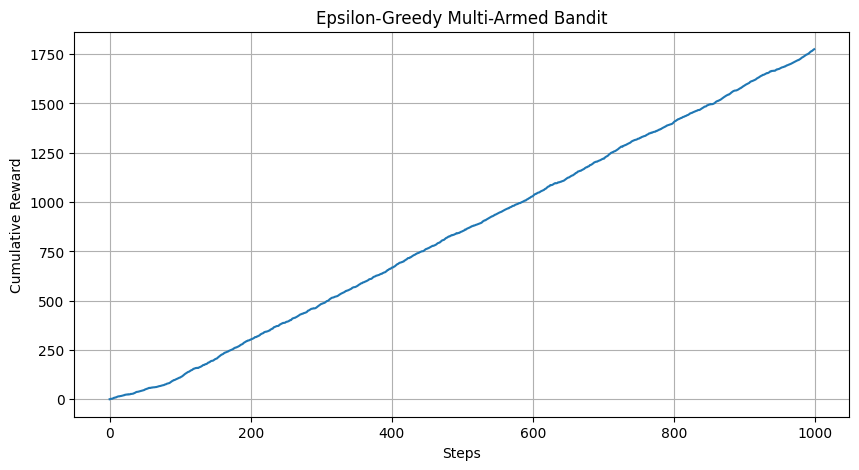

In [6]:
# Calculate cumulative reward
cumulative_rewards = np.cumsum(rewards)

plt.figure(figsize=(10, 5))

plt.plot(cumulative_rewards)

plt.xlabel("Steps")
plt.ylabel("Cumulative Reward")
plt.title("Epsilon-Greedy Multi-Armed Bandit")

plt.grid(True)
plt.show()

## **Plot Arm Selection Frequency**

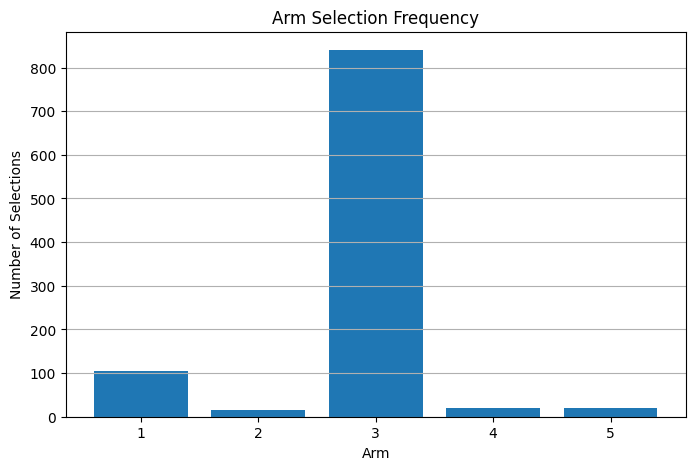

In [7]:
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, n_arms + 1),
    action_counts
)

plt.xlabel("Arm")
plt.ylabel("Number of Selections")
plt.title("Arm Selection Frequency")

plt.xticks(range(1, n_arms + 1))
plt.grid(axis="y")

plt.show()

## **Observation**

1. Initially, the agent does not know which arm gives the highest reward.

2. The ε-greedy strategy allows the agent to explore different arms.

3. During exploitation, the agent selects the arm with the highest estimated reward.

4. As the number of steps increases, the estimated rewards become closer to the actual rewards.

5. Arm 3 has the highest true average reward, so the agent should generally select Arm 3 more frequently.

6. The value of ε controls the balance between exploration and exploitation.

7. The cumulative reward generally increases as the agent learns.

## **Conclusion**

The ε-greedy action selection method was successfully implemented for the Multi-Armed Bandit Problem.

The experiment demonstrated how exploration helps the agent discover better actions, while exploitation allows the agent to use the best-known action.

The agent gradually learned to select the arm with the highest expected reward more frequently.